# Basic Fine-Tuning, การปรับโมเดลเบื้องต้น
จัดทำโดย อ.ดร.ภูริวัจน์ วรวิชัยพัฒน์

Fine-Tuning ในที่นี้ หมายถึง **การปรับแต่งโมเดลพื้นฐานที่เราได้สร้างไว้แล้ว** เพื่อให้ผลลัพธ์ดีขึ้น

ตัวอย่างของการปรับแต่ง เช่น:
- เปลี่ยนจำนวนชั้นของโมเดล (เช่น เพิ่ม Dense layer)
- เพิ่มหรือลดจำนวน neuron ในแต่ละชั้น
- เปลี่ยนจำนวน epoch ที่ใช้ในการ train
- และอื่นๆอีกมากมาย เดี่ยวเราจะค่อยๆเรียนเทคนิคอื่นไป

การทดลองปรับแต่งเหล่านี้จะช่วยให้เราเข้าใจว่าโครงสร้างของโมเดลและพารามิเตอร์ต่างๆ มีผลต่อประสิทธิภาพของ AI อย่างไร

**สิ่งที่เราจะทำในโน้ตบุ๊กนี้**:
1. สร้างโมเดลพื้นฐานด้วยข้อมูล Fashion MNIST
2. ปรับแต่งโครงสร้างหรือพารามิเตอร์บางส่วนของโมเดล
3. ฝึกซ้ำและเปรียบเทียบผลลัพธ์กับโมเดลเดิม

In [2]:
import tensorflow as tf
import tensorflow.keras as keras

import numpy as np
import matplotlib.pyplot as plt
tf.keras.utils.set_random_seed(42)  # ทำให้การทดลองทำซ้ำได้ใกล้เคียงเดิม
print(tf.__version__)
print(keras.__version__)
tf.config.list_physical_devices()

2.21.0
3.15.0


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

### Load data + normalisation

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype(np.float32) / 255
test_images = test_images.astype(np.float32) / 255

In [4]:

def plot_history(history):
    """
    Plots the training and validation accuracy and loss from the training history.
    
    Args:
    - history: A History object. The history object is returned by the `fit` method of a Keras model.
    """
    # Plot accuracy history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot loss history
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()


### วาง Structure model 
เป็นโมเดลแบบง่ายๆ

In [5]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
model.fit(train_images, train_labels, batch_size=128, validation_data=(test_images, test_labels), epochs=5)

/home/sothea/miniconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7566 - loss: 0.7402 - val_accuracy: 0.8081 - val_loss: 0.5727
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8285 - loss: 0.5160 - val_accuracy: 0.8234 - val_loss: 0.5175
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8402 - loss: 0.4748 - val_accuracy: 0.8299 - val_loss: 0.4940
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8465 - loss: 0.4531 - val_accuracy: 0.8343 - val_loss: 0.4806
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8504 - loss: 0.4391 - val_accuracy: 0.8363 - val_loss: 0.4719


## <font color="red">แบบฝึกหัดที่ 1 การปรับ Epoch</font>
1. บันทึก accuracy, loss, val_accuracy, และ val_loss เมื่อ epoch=5
2. ปรับโค้ดด้านล่างให้มี epoch เป็น 10, 15, 20 และทำการรัน โดยให้รัน cell นี้ใหม่ทุกครั้งเพื่อสร้างโมเดลใหม่ จากนั้นบันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายของแต่ละ setting
3. สรุปให้หน่อยว่า epoch เยอะขึ้นแล้วโมเดลประสิทธิภาพเป็นอย่างไร


**แต่!!!!! epoch ที่เยอะเกินไปก็ไม่ดีนะครับ เพราะมันจะเกิดอาการ overfitting**

In [11]:
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=128,validation_data=(test_images, test_labels), epochs=15) # <------ แก้บรรทัดนี้

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7566 - loss: 0.7402 - val_accuracy: 0.8081 - val_loss: 0.5727
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8285 - loss: 0.5160 - val_accuracy: 0.8234 - val_loss: 0.5175
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8402 - loss: 0.4748 - val_accuracy: 0.8299 - val_loss: 0.4940
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8465 - loss: 0.4531 - val_accuracy: 0.8343 - val_loss: 0.4806
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8504 - loss: 0.4391 - val_accuracy: 0.8363 - val_loss: 0.4719
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8531 - loss: 0.4291 - val_accuracy: 0.8376 - val_loss: 0.4658
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8561 - loss: 0.4215 - val_accuracy: 0.8403 - val_loss: 0.4613
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8578 - loss: 0.4155 - val_accuracy: 0.

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

| epoch | accuracy | loss | val_accuracy | val_loss |
|---:|---:|---:|---:|---:|
| 5  | 0.8504 | 0.4391 | 0.8363 | 0.4719 |
| 10 | 0.8606 | 0.4064 | 0.8424 | 0.4531 |
| 15 | 0.8641 | 0.3923 | 0.8434 | 0.4469 |
| 20 | 0.8662 | 0.3839 | 0.8434 | 0.4443 |
> summary: the more numbers of epoch make the accuray value increase less, just like from 15 and 20 the accuracy increase less than
> 0.2 which tell use that the more epoch isn't better we have to choose the accurate one.


## <font color="red">แบบฝึกหัดที่ 2 Relu</font>
1. รันโค้ดด้านล่าง (ที่ epoch=10 และ ไม่มี Relu) จากนั้นบันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายด้วย
2. รันโค้ดด้านล่างอันที่ 2 (มี Relu) จากนั้นบันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายด้วย
3. สรุปให้หน่อยว่ามี relu แล้วส่งผลกระทบให้กับโมเดลอย่างไร

In [12]:
# ไม่มี Relu
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(64),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
model.fit(train_images, train_labels, batch_size=128, validation_data=(test_images, test_labels), epochs=10)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7979 - loss: 0.5886 - val_accuracy: 0.8271 - val_loss: 0.5015
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8427 - loss: 0.4584 - val_accuracy: 0.8354 - val_loss: 0.4747
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8492 - loss: 0.4374 - val_accuracy: 0.8388 - val_loss: 0.4633
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8516 - loss: 0.4260 - val_accuracy: 0.8400 - val_loss: 0.4596
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.4183 - val_accuracy: 0.8392 - val_loss: 0.4612
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8555 - loss: 0.4127 - val_accuracy: 0.8385 - val_loss: 0.4633
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8568 - loss: 0.4082 - val_accuracy: 0.8386 - val_loss: 0.4633
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8582 - loss: 0.4045 - val_accuracy: 0.

In [13]:
# มี Relu
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
model.fit(train_images, train_labels,batch_size=128, validation_data=(test_images, test_labels), epochs=10)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8006 - loss: 0.5908 - val_accuracy: 0.8290 - val_loss: 0.4876
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - loss: 0.4272 - val_accuracy: 0.8414 - val_loss: 0.4484
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8630 - loss: 0.3899 - val_accuracy: 0.8499 - val_loss: 0.4261
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8708 - loss: 0.3672 - val_accuracy: 0.8563 - val_loss: 0.4092
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8759 - loss: 0.3495 - val_accuracy: 0.8597 - val_loss: 0.3984
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8802 - loss: 0.3353 - val_accuracy: 0.8615 - val_loss: 0.3922
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8843 - loss: 0.3233 - val_accuracy: 0.8644 - val_loss: 0.3837
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8871 - loss: 0.3127 - val_accuracy: 0.

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

| โมเดล | accuracy | loss | val_accuracy | val_loss |
|---|---:|---:|---:|---:|
| ไม่มี ReLU | 0.8600 | 0.3987 | 0.8413 | 0.4561 |
| มี ReLU   | 0.8933 | 0.2949 | 0.8706 | 0.3670 |


ข้อที่ 3
> adding ReLU increase both accuracy and the validate accurary and decrease both loss and validate loss, which help train our model better.


## <font color="red">แบบฝึกหัดที่ 3 เพิ่ม node/layer</font>
1. แก้ไขโค้ดด้านล่างโดยเพิ่มจำนวน node ของ dense เป็น 128 จากนั้นบันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายด้วย
2. ใช้โมเดลจากข้อ 1 แล้วเพิ่ม Dense64 เข้าไปก่อน Dense10 เพื่อให้โครงสร้างเป็น Flatten, Dense128, Dense64, Dense10 จากนั้นบันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายด้วย
3. ผลลัพธ์ของการเทรนนั้นเป็นอย่างไร การเพิ่ม layer ช่วยให้ค่า accuracy และ loss สุดท้ายเป็นอย่างไรเทียบระหว่าง 1. และ 2.
4. สังเกตุค่า val_accuracy และ val_loss ในทุกๆ epoch (ถ้าไม่เห็น trend ลองปรับ epoch เป็น 20, 30)
    1. ค่า val_accuracy เพิ่มขึ้นเรื่อยๆหรือไม่? หรือมีค่าเพดานที่ไม่สามารถผ่านไปได้?
    2. ค่า val_loss ลดลงเรื่อยๆหรือไม่? หรือมีการเหวี่ยงขึ้นๆลงๆ? หรือว่า ถึงจุดนึงแล้วเพิ่มขึ้น 

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8123 - loss: 0.5441 - val_accuracy: 0.8443 - val_loss: 0.4437
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8619 - loss: 0.3922 - val_accuracy: 0.8525 - val_loss: 0.4098
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8742 - loss: 0.3524 - val_accuracy: 0.8591 - val_loss: 0.3882
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8810 - loss: 0.3275 - val_accuracy: 0.8623 - val_loss: 0.3766
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8880 - loss: 0.3083 - val_accuracy: 0.8651 - val_loss: 0.3763
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8924 - loss: 0.2920 - val_accuracy: 0.8693 - val_loss: 0.3646
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8979 - loss: 0.2787 - val_accuracy: 0.8704 - val_loss: 0.3669
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9024 - loss: 0.2662 - val_accuracy: 0.

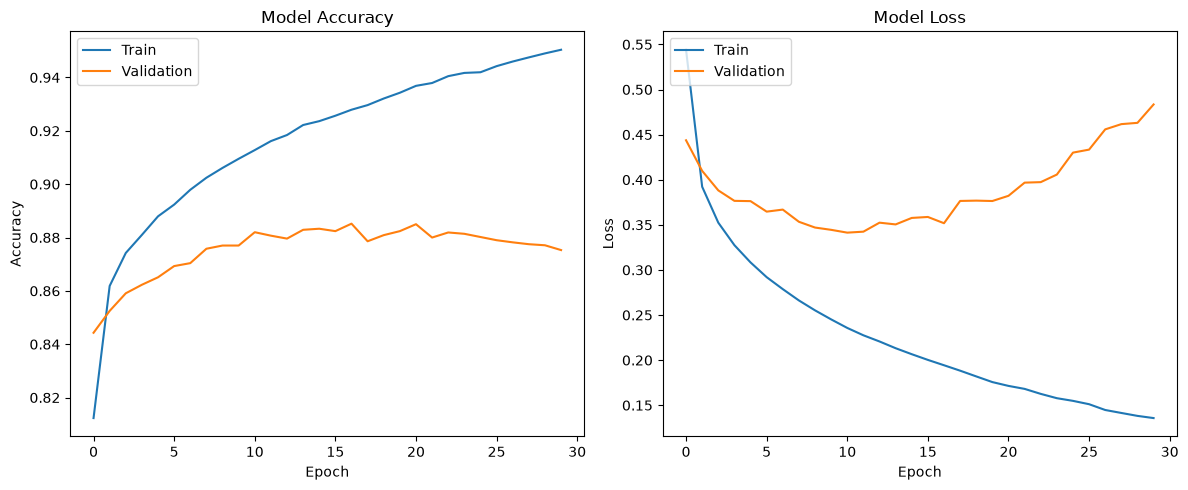

In [17]:
tf.keras.utils.set_random_seed(42)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(64, activation=tf.nn.relu), # <---------- แก้ไขบรรทัดนี้
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history=model.fit(train_images, train_labels,batch_size=128, validation_data=(test_images, test_labels), epochs=30)

plot_history(history)

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

| โครงสร้าง | accuracy | loss | val_accuracy | val_loss |
|---|---:|---:|---:|---:|
| Flatten, Dense128, Dense10 | 0.9063 | 0.2586 | 0.8777 | 0.3524 |
| Flatten, Dense128, Dense64, Dense10 | 0.9095 | 0.2452 | 0.8770 | 0.3444 |

3. when we add more layers, the model has increase the accuray but the validate accuray has decreased (by 0.0007).
4. A. yes, the val_accuracy is increasing but the more we run seem like it has less effect, the increasing value is too big and also it suddently start to decrease as well.

   B. the val_loss is increasing but for some epochs with no specific patterns (increase, decrease) that we can identify it.


## บทสรุป

การปรับโมเดลให้มีความซับซ้อนขึ้น ไม่ว่าจะเป็นการปรับจำนวน node หรือเพิ่ม layer สามารถเพิ่มประสิทธิภาพให้โมเดลได้จริง 
- อย่างไรก็ตามเราไม่สามารถดูที่ค่า accuracy และ loss ได้อย่างเดียว
- ต้องดูค่า val_accuracy และ val_loss ด้วย เป็นการบอกว่าโมเดลทำงานเป็นอย่างไรกับดาต้าที่ไม่เคยเห็นมาก่อน
- สัญญาณของ overfitting มักเห็นได้เมื่อ training loss ลดลงต่อเนื่อง แต่ val_loss เริ่มเพิ่มขึ้น หรือช่องว่างระหว่างผล train กับ validation กว้างขึ้น

**<font color="blue">Overfitting คือปัญหาที่โมเดลจดจำ training dataset มากเกินไป แต่ทำงานได้ไม่ดีกับข้อมูล validation หรือ test ที่ไม่เคยเห็นมาก่อน</font>**